## 🧪 Cài đặt thư viện cần thiết

In [ ]:
!pip install ultralytics==8.2.5
!pip install mlflow
!pip install torch==2.5.1 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install albumentations opencv-python --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.0/755.0 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 65.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-c

## 🔗 Mount Google Drive và giải nén dữ liệu

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!unzip /content/drive/MyDrive/dispatch/dataset.zip -d /content/dataset
!ls /content/dataset/Detection/


Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
  inflating: /content/dataset/Detection/train/labels/img_001196.txt  
  inflating: /content/dataset/Detection/train/labels/img_001000.txt  
  inflating: /content/dataset/Detection/train/labels/img_000759.txt  
  inflating: /content/dataset/Detection/train/labels/img_000646.txt  
  inflating: /content/dataset/Detection/train/labels/img_000262.txt  
  inflating: /content/dataset/Detection/train/labels/img_000431.txt  
  inflating: /content/dataset/Detection/train/labels/img_001068.txt  
  inflating: /content/dataset/Detection/train/labels/img_000825.txt  
  inflating: /content/dataset/Detection/train/labels/img_000490.txt  
  inflating: /content/dataset/Detection/train/labels/img_000414.txt  
  inflating: /content/dataset/Detection/train/labels/img_001141.txt  
  inflating: /content/dataset/Detection/train/labels/img_000446.txt  
  inflating: /content/dataset/Detection/train/labels/img_000394.txt  
  inflating: /content/dataset/Det

In [ ]:
import os
# 🔕 Disable W&B logging before importing Ultralytics
!pip uninstall -y wandb
os.environ["WANDB_DISABLED"] = "true"

Found existing installation: wandb 0.21.0
Uninstalling wandb-0.21.0:
  Successfully uninstalled wandb-0.21.0


📁 Train images: /content/dataset/Detection/train/images
📁 Train labels: /content/dataset/Detection/train/labels
🔢 Classes: ['dish', 'tray']


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


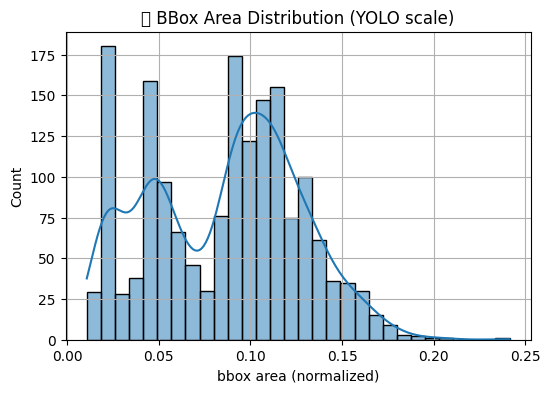

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


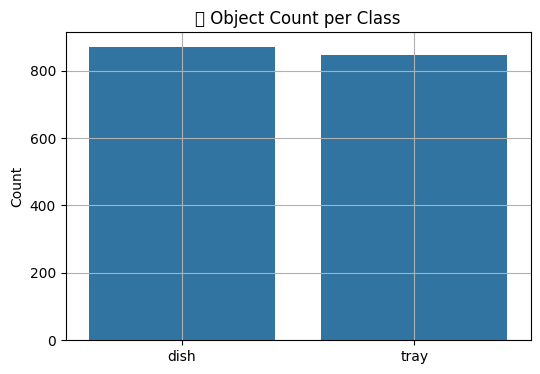

In [ ]:
# 📊 Dataset Analysis before Training (Fixed for your structure)
import os
import yaml
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

# ========== Load dataset.yaml ==========
dataset_yaml = "/content/dataset/Detection/dataset.yaml"
with open(dataset_yaml, 'r') as f:
    data_cfg = yaml.safe_load(f)

dataset_root = Path(data_cfg['path'])
train_img_dir = dataset_root / data_cfg['train']   # train/images
val_img_dir = dataset_root / data_cfg['val']       # val/images
train_lbl_dir = dataset_root / "train/labels"
val_lbl_dir = dataset_root / "val/labels"
class_names = data_cfg['names']

print(f"📁 Train images: {train_img_dir}")
print(f"📁 Train labels: {train_lbl_dir}")
print(f"🔢 Classes: {class_names}")

# ========== Analyze dataset ==========
def analyze_dataset(img_dir, lbl_dir):
    image_sizes = []
    bbox_areas = []
    class_counts = {i: 0 for i in range(len(class_names))}
    image_exts = [".jpg", ".jpeg", ".png"]

    for img_path in img_dir.glob("*"):
        if img_path.suffix.lower() not in image_exts:
            continue
        lbl_path = lbl_dir / (img_path.stem + ".txt")
        if not lbl_path.exists():
            continue

        with Image.open(img_path) as img:
            w, h = img.size
            image_sizes.append((w, h))

        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls, x, y, bw, bh = map(float, parts)
                class_counts[int(cls)] += 1
                bbox_areas.append(bw * bh)  # normalized area

    return image_sizes, bbox_areas, class_counts

# Run analysis on training set
img_sizes, bbox_areas, class_dist = analyze_dataset(train_img_dir, train_lbl_dir)

# ========== Visualize ==========
# BBox area distribution
plt.figure(figsize=(6,4))
sns.histplot(bbox_areas, bins=30, kde=True)
plt.title("📏 BBox Area Distribution (YOLO scale)")
plt.xlabel("bbox area (normalized)")
plt.grid()
plt.show()

# Class distribution
plt.figure(figsize=(6,4))
sns.barplot(x=[class_names[k] for k in class_dist.keys()], y=list(class_dist.values()))
plt.title("📊 Object Count per Class")
plt.ylabel("Count")
plt.grid()
plt.show()



📦 1. Biểu đồ diện tích bounding box (BBox Area Distribution)
Nhận xét:

Khoảng 30–40% các object có diện tích nhỏ hơn 0.05 (trên thang YOLO normalized).

Phân bố không đều, có nhiều đỉnh → có thể do object size thay đổi mạnh giữa các ảnh.

Đề xuất cải thiện:

✅ Tăng imgsz khi training YOLO (ví dụ: từ 640 ➜ 960 hoặc 1088) để giúp YOLO học được các object nhỏ.

✅ Tăng augmentation với các object nhỏ:

mosaic=1.0, copy_paste=0.2, hsv_h=0.015...

❗ Tránh giảm chất lượng ảnh quá mức khi resize.


📦 2. Biểu đồ phân bố object theo class (Object Count per Class)
Nhận xét:

Cân bằng tuyệt vời 🟢: Số lượng dish và tray gần bằng nhau (~850 mỗi class).

Không có class nào bị thiếu hoặc overrepresented.

Hành động:

✅ Không cần oversampling hay re-weighting loss function.

✅ Có thể dùng default class weights khi huấn luyện.

## 🎨 Augmentation sinh vật thể nhỏ mô phỏng thực tế

In [20]:
import albumentations as A
import cv2
from pathlib import Path

# --- AUGMENTATION PIPELINES ---
# Common augment (for images with both dish and tray)
transform = A.Compose([
    A.OneOf([
        A.RandomResizedCrop(size=(1088, 1088), scale=(0.7, 1.0), ratio=(0.8, 1.2), p=0.6),
        A.PadIfNeeded(min_height=1088, min_width=1088, p=0.4)
      ], p=1.0),
    A.RandomBrightnessContrast(brightness_limit=(0.05, 0.15), contrast_limit=(0.3, 0.5), p=1.0),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=20, p=0.5),
    A.RandomGamma(gamma_limit=(90, 120), p=0.4),
    A.CLAHE(clip_limit=4.0, tile_grid_size=(4, 4), p=0.4),
    A.GaussNoise(p=0.2),
    A.RandomShadow(shadow_roi=(0, 0.5, 1, 1), p=0.3),
    A.MotionBlur(blur_limit=3, p=0.2),
    A.Perspective(scale=(0.015, 0.04), p=0.5),
    # A.Resize(1088, 1088),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.3))

# Aug riêng cho tray
# tray_transform = A.Compose([
#     A.OneOf([
#         A.RandomResizedCrop(size=(1088, 1088), scale=(0.1, 0.15), ratio=(0.8, 1.2), p=0.6),
#         A.PadIfNeeded(min_height=1088, min_width=1088, value=114, p=0.4)
#       ], p=1.0),
#     A.RandomBrightnessContrast(brightness_limit=(0.05, 0.15), contrast_limit=(0.3, 0.6), p=1.0),
#     A.CLAHE(clip_limit=4.0, tile_grid_size=(4, 4), p=0.3),
#     A.Equalize(p=0.4),
#     A.ISONoise(color_shift=(0.01, 0.1), intensity=(0.1, 0.5), p=0.2),
#     A.Perspective(scale=(0.05, 0.08), p=0.6),
#     A.RandomShadow(p=0.3),
#     # A.Resize(1088, 1088),
# ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.2))

# Aug riêng cho dish
# dish_transform = A.Compose([
#     A.OneOf([
#         A.RandomResizedCrop(size=(1088, 1088), scale=(0.1, 0.15), ratio=(0.8, 1.2), p=0.6),
#         A.PadIfNeeded(min_height=1088, min_width=1088, value=114, p=0.4)
#       ], p=1.0),
#     A.RandomBrightnessContrast(brightness_limit=(-0.2, 0.3), contrast_limit=(-0.2, 0.3), p=0.8),
#     A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.6),
#     A.MotionBlur(blur_limit=3, p=0.2),
#     A.GaussNoise(var_limit=(5.0, 25.0), p=0.2),
#     A.Perspective(scale=(0.02, 0.04), p=0.5),
#     A.Rotate(limit=15, p=0.4),
#     A.HorizontalFlip(p=0.5),
#     # A.Resize(1088, 1088),
# ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.3))


In [23]:
dish_transform = A.Compose([
    A.OneOf([
        A.Affine(
            scale=(0.15, 0.25),  # 👈 thu nhỏ
            translate_percent={"x": (-0.4, 0.4), "y": (-0.4, 0.4)},
            fit_output=True,
            border_mode=cv2.BORDER_CONSTANT,
            p=0.7),
        A.RandomResizedCrop((1088, 1088), scale=(0.7, 1.0), ratio=(0.9, 1.1), p=0.3)
    ], p=1.0),

    A.CropAndPad(percent=(-0.05, 0.05), border_mode=cv2.BORDER_CONSTANT, p=0.3),  # 👈 thêm sự không hoàn chỉnh ở rìa

    A.RandomBrightnessContrast(brightness_limit=(-0.3, 0.4), contrast_limit=(-0.3, 0.4), p=0.9),
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=25, val_shift_limit=20, p=0.7),
    A.RandomShadow(shadow_roi=(0, 0.5, 1, 1), p=0.4),
    A.MotionBlur(blur_limit=3, p=0.2),
    A.GaussNoise(p=0.2),
    A.Rotate(limit=10, p=0.3),
    A.HorizontalFlip(p=0.5),

    A.PadIfNeeded(min_height=1088, min_width=1088, border_mode=0, p=1.0)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.2))

In [22]:
tray_transform = A.Compose([
    A.OneOf([
        A.Affine(
            scale=(0.2, 0.35),  # 👈 Làm tray nhỏ hơn nữa
            translate_percent={"x": (-0.4, 0.4), "y": (-0.4, 0.4)},
            rotate=(-10, 10),
            fit_output=True,
            border_mode=cv2.BORDER_CONSTANT,
            p=0.7
        ),
        A.RandomResizedCrop(size=(1088, 1088), scale=(0.7, 1.0), ratio=(0.8, 1.2), p=0.3)
    ], p=1.0),

    A.RandomBrightnessContrast(brightness_limit=(0.05, 0.2), contrast_limit=(0.2, 0.4), p=1.0),
    A.CLAHE(clip_limit=4.0, tile_grid_size=(4, 4), p=0.4),
    A.Equalize(p=0.2),
    A.ISONoise(color_shift=(0.01, 0.1), intensity=(0.1, 0.5), p=0.3),
    A.Perspective(scale=(0.05, 0.08), p=0.6),
    A.RandomShadow(shadow_roi=(0, 0.5, 1, 1), p=0.4),

    A.PadIfNeeded(1088, 1088, border_mode=0, p=1.0)
], bbox_params=A.BboxParams(
    format='yolo',
    label_fields=['class_labels'],
    min_visibility=0.1))  # 👈 Giảm để giữ các tray nhỏ

:## 🧪 Sinh ảnh augment kèm nhãn (YOLO) và resize chuẩn

In [ ]:
# --- AUGMENTATION FUNCTION ---
def augment_images_with_labels(image_dir, label_dir, output_img_dir, output_lbl_dir, n_aug=2):
    image_dir = Path(image_dir)
    label_dir = Path(label_dir)
    output_img_dir = Path(output_img_dir)
    output_lbl_dir = Path(output_lbl_dir)
    output_img_dir.mkdir(parents=True, exist_ok=True)
    output_lbl_dir.mkdir(parents=True, exist_ok=True)

    image_paths = list(image_dir.glob("*.jpg")) + list(image_dir.glob("*.png"))
    total_aug = 0

    for img_path in image_paths:
        label_path = label_dir / (img_path.stem + ".txt")
        if not label_path.exists():
            continue

        image = cv2.imread(str(img_path))
        h, w = image.shape[:2]

        bboxes = []
        class_labels = []
        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls, x, y, bw, bh = map(float, parts)
                bboxes.append([x, y, bw, bh])
                class_labels.append(int(cls))

        if not bboxes:
            continue

        # --- Chọn transform phù hợp theo class ---
        if all(cls == 0 for cls in class_labels):
            selected_transform = dish_transform
        elif all(cls == 1 for cls in class_labels):
            selected_transform = tray_transform
        else:
            selected_transform = transform  # dùng transform chung cho ảnh mixed

        for i in range(n_aug):
            try:
                augmented = selected_transform(
                    image=image,
                    bboxes=bboxes,
                    class_labels=class_labels
                )
            except Exception as e:
                print(f"❌ Aug failed on {img_path.name}: {e}")
                continue

            aug_img = augmented["image"]
            aug_bboxes = augmented["bboxes"]
            aug_classes = augmented["class_labels"]

            if not aug_bboxes:
                continue

            aug_name = f"{img_path.stem}_aug{i}"
            aug_img_path = output_img_dir / f"{aug_name}.jpg"
            aug_lbl_path = output_lbl_dir / f"{aug_name}.txt"

            cv2.imwrite(str(aug_img_path), aug_img)
            with open(aug_lbl_path, "w") as f:
                for bbox, cls in zip(aug_bboxes, aug_classes):
                    f.write(f"{cls} {' '.join(map(str, bbox))}\n")

            total_aug += 1

    print(f"✅ Đã tạo {total_aug} ảnh augment + nhãn tại {output_img_dir}")


## ▶️ Gọi augment trên thư mục train

In [ ]:
import cv2
from pathlib import Path

augment_images_with_labels(
    image_dir="/content/dataset/Detection/train/images",
    label_dir="/content/dataset/Detection/train/labels",
    output_img_dir="/content/dataset/Detection/train/images_aug",
    output_lbl_dir="/content/dataset/Detection/train/labels_aug",
    n_aug=2
)


✅ Đã tạo 1621 ảnh augment + nhãn tại /content/dataset/Detection/train/images_aug


In [ ]:
# shutil.rmtree('/content/runs', ignore_errors=True)


In [ ]:
from pathlib import Path

def check_aug_image_label_match(image_dir, label_dir):
    image_dir = Path(image_dir)
    label_dir = Path(label_dir)

    image_stems = set(p.stem for p in image_dir.glob("*.jpg")) | set(p.stem for p in image_dir.glob("*.png"))
    label_stems = set(p.stem for p in label_dir.glob("*.txt"))

    matched = image_stems & label_stems
    img_only = image_stems - label_stems
    lbl_only = label_stems - image_stems

    print(f"🧪 Tổng ảnh augment: {len(image_stems)}")
    print(f"🏷️ Tổng nhãn augment: {len(label_stems)}")
    print(f"✅ Khớp đúng: {len(matched)}")
    print(f"⚠️ Ảnh KHÔNG có nhãn: {len(img_only)}")
    if img_only:
        print("  🔸 Ví dụ ảnh thiếu nhãn:")
        for name in list(img_only)[:5]:
            print(f"    ⚠️ {name}.jpg")
    print(f"⚠️ Nhãn KHÔNG có ảnh: {len(lbl_only)}")
    if lbl_only:
        print("  🔸 Ví dụ nhãn thiếu ảnh:")
        for name in list(lbl_only)[:5]:
            print(f"    ⚠️ {name}.txt")

# Kiểm tra trong thư mục augment
check_aug_image_label_match(
    image_dir="/content/dataset/Detection/train/images_aug",
    label_dir="/content/dataset/Detection/train/labels_aug"
)


🧪 Tổng ảnh augment: 1621
🏷️ Tổng nhãn augment: 1621
✅ Khớp đúng: 1621
⚠️ Ảnh KHÔNG có nhãn: 0
⚠️ Nhãn KHÔNG có ảnh: 0


In [ ]:
from pathlib import Path
import shutil

base_path = Path("/content/dataset/Detection")

# === 1. Gộp ảnh + nhãn augment và train/labels
aug_img_dir = base_path / "train/images_aug"
aug_lbl_dir = base_path / "train/labels_aug"
train_lbl_dir = base_path / "train/labels"

merged_img_count = 0
merged_lbl_count = 0

if aug_img_dir.exists():
    for file in aug_img_dir.glob("*.[jp][pn]g"):
        shutil.move(str(file), train_img_dir / file.name)
        merged_img_count += 1

if aug_lbl_dir.exists():
    for file in aug_lbl_dir.glob("*.txt"):
        shutil.move(str(file), train_lbl_dir / file.name)
        merged_lbl_count += 1

print(f"✅ Đã gộp {merged_img_count} ảnh và {merged_lbl_count} nhãn augment vào tập train.")

# === 2. Xoá thư mục tạm: ảnh & nhãn augment
temp_dirs = [
    base_path / "train/images_aug",
    base_path / "train/labels_aug"
]

for aug_dir in temp_dirs:
    if aug_dir.exists():
        shutil.rmtree(aug_dir)
        print(f"🧹 Đã xoá thư mục tạm: {aug_dir}")

# === 3. Xoá file cache YOLO nếu có
for subset in ["train", "val"]:
    cache_path = base_path / subset / "images.cache"
    if cache_path.exists():
        cache_path.unlink()
        print(f"🗑️ Đã xoá file cache: {cache_path.name}")


✅ Đã gộp 1621 ảnh và 1621 nhãn augment vào tập train.
🧹 Đã xoá thư mục tạm: /content/dataset/Detection/train/images_aug
🧹 Đã xoá thư mục tạm: /content/dataset/Detection/train/labels_aug


In [ ]:
from pathlib import Path

def check_image_label_validity(image_dir, label_dir):
    image_dir = Path(image_dir)
    label_dir = Path(label_dir)

    imgs = set(p.stem for p in image_dir.glob("*.jpg")) | set(p.stem for p in image_dir.glob("*.png"))
    lbls = set(p.stem for p in label_dir.glob("*.txt"))

    matched = imgs & lbls
    unmatched = imgs - lbls

    print(f"\n📁 📦 Tổng hợp kiểm tra tại {image_dir.parent.name.upper()}")
    print(f"📸 Tổng số ảnh: {len(imgs)}")
    print(f"🏷️  Tổng số file nhãn: {len(lbls)}")
    print(f"✅  Ảnh có nhãn hợp lệ: {len(matched)}")
    print(f"⚠️  Ảnh KHÔNG có nhãn: {len(unmatched)}")

    if unmatched:
        print("🧐 Một số ảnh thiếu nhãn:")
        for name in list(unmatched)[:5]:
            print(f"  ⚠️ {name}.jpg")

# Áp dụng cho train và val
check_image_label_validity(
    image_dir="/content/dataset/Detection/train/images",
    label_dir="/content/dataset/Detection/train/labels"
)

check_image_label_validity(
    image_dir="/content/dataset/Detection/val/images",
    label_dir="/content/dataset/Detection/val/labels"
)



📁 📦 Tổng hợp kiểm tra tại TRAIN
📸 Tổng số ảnh: 2661
🏷️  Tổng số file nhãn: 2661
✅  Ảnh có nhãn hợp lệ: 2661
⚠️  Ảnh KHÔNG có nhãn: 0

📁 📦 Tổng hợp kiểm tra tại VAL
📸 Tổng số ảnh: 261
🏷️  Tổng số file nhãn: 261
✅  Ảnh có nhãn hợp lệ: 261
⚠️  Ảnh KHÔNG có nhãn: 0


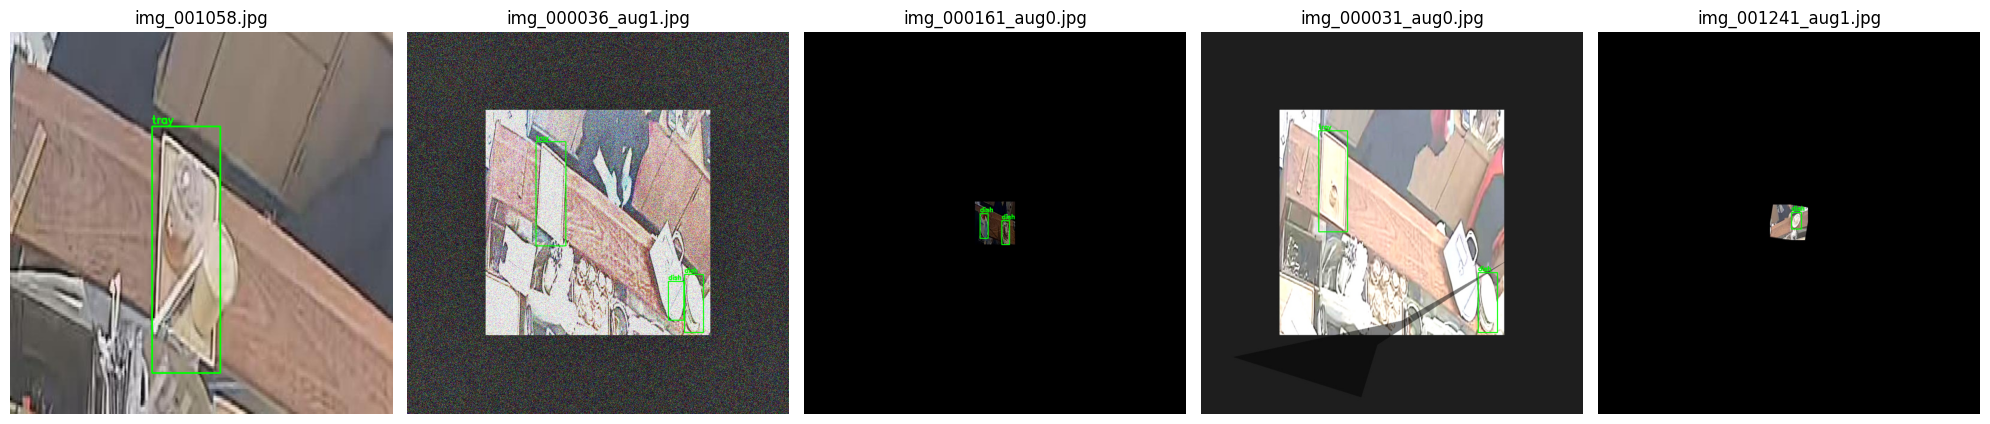

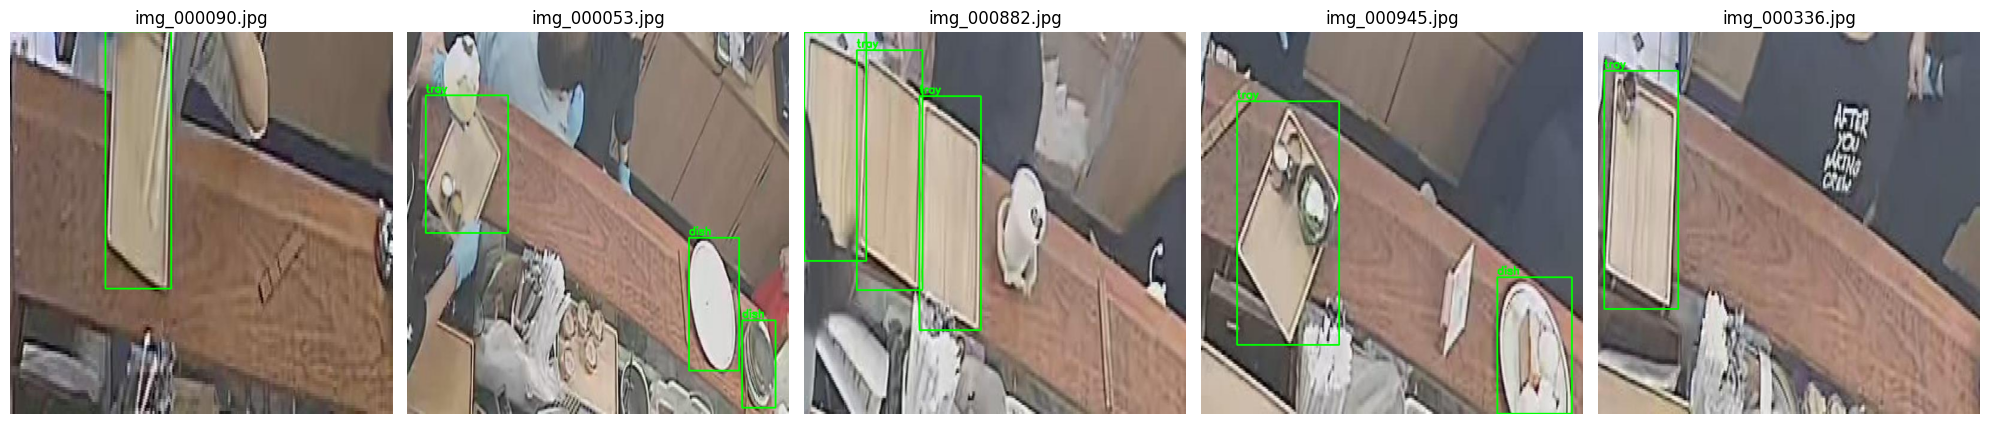

In [ ]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import random

def draw_bbox_yolo(image_path, label_path, class_names=None):
    img = cv2.imread(str(image_path))
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if not label_path.exists():
        return img  # no bbox

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls_id, x_center, y_center, bw, bh = map(float, parts)
            x1 = int((x_center - bw / 2) * w)
            y1 = int((y_center - bh / 2) * h)
            x2 = int((x_center + bw / 2) * w)
            y2 = int((y_center + bh / 2) * h)
            color = (0, 255, 0)
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            label = class_names[int(cls_id)] if class_names else str(int(cls_id))
            cv2.putText(img, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    return img

def visualize_random_bboxes(image_dir, label_dir, n=5, class_names=None):
    image_dir = Path(image_dir)
    label_dir = Path(label_dir)

    image_paths = list(image_dir.glob("*.jpg")) + list(image_dir.glob("*.png"))
    image_paths = [p for p in image_paths if (label_dir / f"{p.stem}.txt").exists()]
    if not image_paths:
        print("⚠️ Không tìm thấy ảnh nào có nhãn hợp lệ.")
        return

    selected = random.sample(image_paths, min(n, len(image_paths)))

    fig, axes = plt.subplots(1, len(selected), figsize=(20, 6))
    if len(selected) == 1:
        axes = [axes]

    for ax, img_path in zip(axes, selected):
        label_path = label_dir / f"{img_path.stem}.txt"
        img = draw_bbox_yolo(img_path, label_path, class_names)
        ax.imshow(img)
        ax.set_title(img_path.name)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# 🔍 Gọi cho tập train
visualize_random_bboxes(
    image_dir="/content/dataset/Detection/train/images",
    label_dir="/content/dataset/Detection/train/labels",
    n=5,
    class_names=["dish", "tray"]
)

# 🔍 Gọi cho tập val
visualize_random_bboxes(
    image_dir="/content/dataset/Detection/val/images",
    label_dir="/content/dataset/Detection/val/labels",
    n=5,
    class_names=["dish", "tray"]
)

## 🚀 Huấn luyện YOLOv8 tối ưu cho object nhỏ

In [18]:
from ultralytics import YOLO
import mlflow
import torch

mlflow.set_tracking_uri("https://442e3fa6f0a5.ngrok-free.app")
mlflow.set_experiment("dispatch-detection-v1")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_params = {
    "model": "yolov8n",
    "epochs": 67,
    "imgsz": 1088,
    "batch": 8,
    "patience": 20,

    # Chỉ giữ các augment nhẹ, bổ trợ
    "hsv_h": 0.005,         # rất nhẹ, vì đã HSV trong albumentations
    "copy_paste": 0.1,      # giữ nhẹ nếu thiếu tray/dish nhỏ
    "mosaic": 0.5,          # chỉ dùng nhẹ nếu ảnh ít object
    "scale": 0.2,           # tránh làm méo object quá nhiều
    "translate": 0.05,      # không dịch nhiều (ảnh bạn gần như cố định)
    "perspective": 0.0,     # disable vì đã augment tay rồi
    "fliplr": 0.3,          # giữ ở mức vừa phải
    "flipud": 0.0,          # KHÔNG dùng trong context camera cố định
    "degrees": 0.0,         # không xoay trong YOLO vì đã xoay rồi trước đó
    "workers": 2,           # Số workers nhỏ tránh overload RAM/CPU Colab
    "cache": False,          # Tăng tốc nếu dữ liệu nhỏ vừa RAM (không dùng nếu RAM < 15GB)
    "note": "Tối ưu augment thủ công, YOLO chỉ dùng hỗ trợ nhẹ, epoch 25"
}


with mlflow.start_run(run_name="yolov8n_object_small"):
    mlflow.log_params(train_params)

    ### new training  ###
    # model = YOLO("yolov8n.pt")

    ### retraining   ###
    model = YOLO("/content/runs/detect/yolov8n_dispatch_augments_epoch/weights/last.pt")

    results = model.train(
        data="/content/dataset/Detection/dataset.yaml",
        device=device,
        name="yolov8n_dispatch_augments_epoch",  # 👈 tránh ghi đè vào thư mục cũ
        # resume=True, ## Cần thiết cho retrain
        **{k: v for k, v in train_params.items() if k not in ["model", "note"]}
    )

    if hasattr(results, "metrics"):
        mlflow.log_metrics({
            "map50": results.metrics.box.map50,
            "map": results.metrics.box.map,
            "precision": results.metrics.box.precision,
            "recall": results.metrics.box.recall
        })


New https://pypi.org/project/ultralytics/8.3.167 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=detect, mode=train, model=/content/runs/detect/yolov8n_dispatch_augments_epoch/weights/last.pt, data=/content/dataset/Detection/dataset.yaml, epochs=67, time=None, patience=20, batch=8, imgsz=1088, save=True, save_period=-1, cache=False, device=cuda, workers=2, project=None, name=yolov8n_dispatch_augments_epoch2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=Fal

train: Scanning /content/dataset/Detection/train/labels.cache... 2661 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2661/2661 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



/usr/local/lib/python3.11/dist-packages/ultralytics/data/augment.py:891: UserWarning: Argument(s) 'quality_lower' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, p=0.0),
/usr/local/lib/python3.11/dist-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()
val: Scanning /content/dataset/Detection/val/labels.cache... 261 images, 0 backgrounds, 0 corrupt: 100%|██████████| 261/261 [00:00<?, ?it/s]


Plotting labels to runs/detect/yolov8n_dispatch_augments_epoch2/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001667, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)


...

                   all        261        374      0.997      0.981      0.992       0.93



67 epochs completed in 2.264 hours.
Optimizer stripped from runs/detect/yolov8n_dispatch_augments_epoch2/weights/last.pt, 6.4MB
Optimizer stripped from runs/detect/yolov8n_dispatch_augments_epoch2/weights/best.pt, 6.4MB

Validating runs/detect/yolov8n_dispatch_augments_epoch2/weights/best.pt...
Ultralytics YOLOv8.2.5 🚀 Python-3.11.13 torch-2.5.1+cu118 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 168 layers, 3006038 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:07<00:00,  2.14it/s]


                   all        261        374      0.997      0.981      0.992      0.931
                  dish        261        175          1      0.983      0.995      0.934
                  tray        261        199      0.994       0.98      0.989      0.928
Speed: 1.0ms preprocess, 7.2ms inference, 0.0ms loss, 4.0ms postprocess per image
Results saved to runs/detect/yolov8n_dispatch_augments_epoch2
🏃 View run yolov8n_object_small at: https://442e3fa6f0a5.ngrok-free.app/#/experiments/628411768526447421/runs/6fc7e5f21e394bb18eb9b9bb7909a312
🧪 View experiment at: https://442e3fa6f0a5.ngrok-free.app/#/experiments/628411768526447421


MlflowException: API request to https://442e3fa6f0a5.ngrok-free.app/api/2.0/mlflow-artifacts/artifacts/628411768526447421/6fc7e5f21e394bb18eb9b9bb7909a312/artifacts/weights/best.pt failed with exception HTTPSConnectionPool(host='442e3fa6f0a5.ngrok-free.app', port=443): Max retries exceeded with url: /api/2.0/mlflow-artifacts/artifacts/628411768526447421/6fc7e5f21e394bb18eb9b9bb7909a312/artifacts/weights/best.pt (Caused by ResponseError('too many 500 error responses'))

✅ Nhận định tổng thể:
Mô hình rất tốt – gần như tiệm cận mức lý tưởng:

Precision và Recall đều trên 0.98 cho cả 2 class.

mAP@0.5 ~ 0.99, nghĩa là mô hình cực kỳ chính xác trong phát hiện object.

mAP@0.5:0.95 ~ 0.925, cho thấy mô hình cũng ổn định ở các mức IoU khó hơn.

🔍 Phân tích theo từng lớp
🔹 dish:
Precision: 0.998 ➜ gần như không có false positive.

Recall: 0.983 ➜ tỷ lệ miss object rất thấp (~1.7%).

mAP@0.5:0.95: 0.932 ➜ độ chính xác cao cả với bbox nhỏ/khó.

🔹 tray:
Precision: 0.979 ➜ có một ít false positive.

Recall: 0.985 ➜ nhận diện tốt đối tượng tray.

mAP@0.5:0.95: 0.918 ➜ vẫn rất tốt, chỉ hơi thấp hơn dish.

🔸 Lưu ý nhỏ: Nếu mục tiêu của bạn cần phân biệt rất rõ giữa tray và dish, bạn có thể theo dõi thêm confusion matrix để biết có bị nhầm giữa 2 lớp không.

In [19]:
!zip -r runs_yolo_clean_aug.zip runs/
from google.colab import files
files.download("runs_yolo_clean_aug.zip")

  adding: runs/ (stored 0%)
  adding: runs/detect/ (stored 0%)
  adding: runs/detect/yolov8n_dispatch_augments_epoch2/ (stored 0%)
  adding: runs/detect/yolov8n_dispatch_augments_epoch2/P_curve.png (deflated 23%)
  adding: runs/detect/yolov8n_dispatch_augments_epoch2/train_batch18981.jpg (deflated 28%)
  adding: runs/detect/yolov8n_dispatch_augments_epoch2/val_batch0_pred.jpg (deflated 2%)
  adding: runs/detect/yolov8n_dispatch_augments_epoch2/PR_curve.png (deflated 24%)
  adding: runs/detect/yolov8n_dispatch_augments_epoch2/results.csv (deflated 85%)
  adding: runs/detect/yolov8n_dispatch_augments_epoch2/val_batch1_labels.jpg (deflated 2%)
  adding: runs/detect/yolov8n_dispatch_augments_epoch2/train_batch1.jpg (deflated 10%)
  adding: runs/detect/yolov8n_dispatch_augments_epoch2/train_batch18983.jpg (deflated 15%)
  adding: runs/detect/yolov8n_dispatch_augments_epoch2/args.yaml (deflated 54%)
  adding: runs/detect/yolov8n_dispatch_augments_epoch2/weights/ (stored 0%)
  adding: runs/de

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Lưu tạm /content/runs/ vào /content/drive/MyDrive/dispatch/runs để ngày mai train tiếp

In [ ]:
import shutil

# Tạo thư mục đích nếu chưa có
!mkdir -p /content/drive/MyDrive/dispatch

# Sao chép toàn bộ thư mục runs/ vào Drive
shutil.copytree('/content/runs', '/content/drive/MyDrive/dispatch/runs', dirs_exist_ok=True)
print("✅ Sao chép runs/ vào Drive thành công.")


Copy thư mục runs/ từ Drive ngược lại Colab để train tiếp

In [ ]:
import shutil

# Xóa thư mục runs/ cũ nếu có (để tránh trùng lặp hoặc lỗi)
!rm -rf /content/runs

# Copy từ Drive ngược lại vào Colab
shutil.copytree('/content/drive/MyDrive/dispatch/runs', '/content/runs', dirs_exist_ok=True)
print("✅ Khôi phục runs/ từ Drive vào Colab thành công.")
